# 🧠 Notebook 01 — Probing VL-JEPA / I-JEPA
### NEidl Egocentric Project — Workshop, Summer 2026

**Goal**: Understand Joint-Embedding Predictive Architectures from the inside out.  
By the end of this notebook you will be able to:
- Explain *why* predicting in embedding space is preferable to pixel/token prediction
- Extract and interpret patch embeddings from a pretrained I-JEPA model
- Implement a simple anomaly detector based on embedding-space distances — the direct precursor to the project's *Intrinsic Anomaly Detection* task

**Estimated time**: 60–75 minutes  
**Prerequisites**: PyTorch, basic Transformer knowledge

---
> 📖 **Primary references**  
> - Assran et al. (2023) *Self-Supervised Learning from Images with a Joint-Embedding Predictive Architecture* [ArXiv:2301.08243]  
> - Chen et al. (2025) *VL-JEPA: Joint Embedding Predictive Architecture for Vision-Language* [ArXiv:2512.10942]

## 🛠️ Setup
Run this cell first. It installs dependencies (idempotent — safe to re-run).

In [3]:
%%capture
# Install required packages — takes ~60 seconds on first run
import subprocess, sys
pkgs = [
    'torch torchvision',
    'timm',                          # ViT models + pretrained weights
    'transformers',                  # HuggingFace (for VL-JEPA tokenizer)
    'einops',                        # Readable tensor rearranging
    'matplotlib seaborn',
    'scikit-learn',
    'umap-learn',                    # UMAP for embedding visualization
    'Pillow requests',
]
for pkg in pkgs:
    subprocess.run([sys.executable, '-m', 'pip', 'install', '-q'] + pkg.split())

In [8]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision.transforms as T
import torchvision.datasets as datasets

import timm
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from PIL import Image
import requests
from io import BytesIO
from copy import deepcopy
from einops import rearrange



In [ ]:
if torch.backends.mps.is_available():
    print("MPS is supported.")
    device = torch.device("mps") if torch.backends.mps.is_available() else torch.device("cpu")
    print(f"Using device: {device}")

    # Run a quick test tensor operation
    x = torch.ones(1, device=device)
    print(x)

else:
    print("MPS is not available.")
    DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
    print(f'Device: {DEVICE}')
    print(f'PyTorch: {torch.__version__}')
    print(f'timm: {timm.__version__}')  
    



MPS is supported.
Using device: mps
tensor([1.], device='mps:0')


---
## Part 1 — Warm Up: Why Embedding-Space Prediction?

Before touching any model, let's build intuition with a simple numerical experiment.  
LeCun's argument: for autoregressive models, the probability of a correct length-$n$ answer is $(1-\varepsilon)^n$, which decays exponentially.

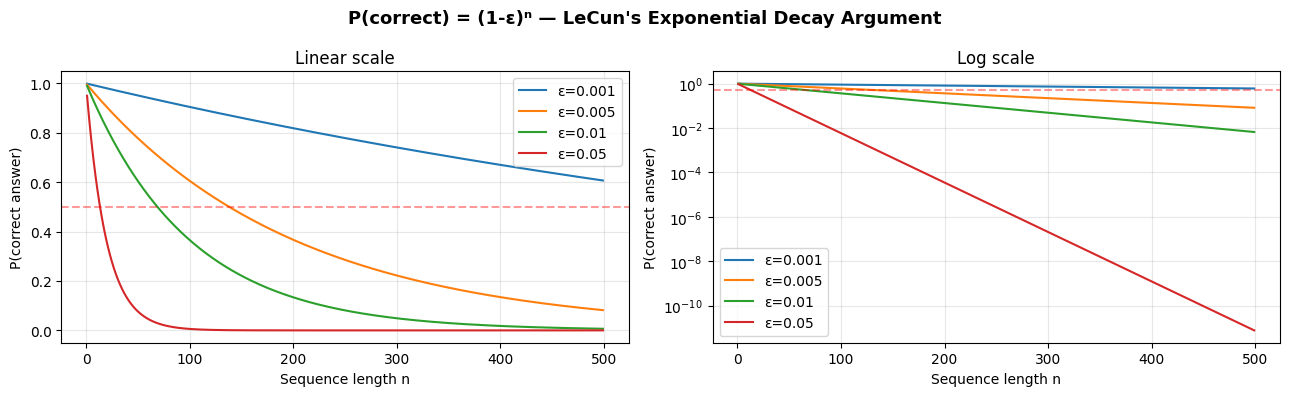

P(correct) at specific sequence lengths:
ε        n=10         n=100        n=1000      
0.001    0.9900       0.904792     3.68e-01    
0.005    0.9511       0.605770     6.65e-03    
0.01     0.9044       0.366032     4.32e-05    
0.05     0.5987       0.005921     5.29e-23    


In [10]:
# === LeCun's exponential decay argument ===
epsilons = [0.001, 0.005, 0.01, 0.05]  # per-token error rates
ns = np.arange(1, 500)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for eps in epsilons:
    p_correct = (1 - eps) ** ns
    axes[0].plot(ns, p_correct, label=f'ε={eps}')
    axes[1].semilogy(ns, p_correct, label=f'ε={eps}')

for ax, title in zip(axes, ['Linear scale', 'Log scale']):
    ax.set_xlabel('Sequence length n')
    ax.set_ylabel('P(correct answer)')
    ax.set_title(title)
    ax.legend()
    ax.axhline(0.5, color='red', linestyle='--', alpha=0.4, label='50% threshold')
    ax.grid(True, alpha=0.3)

plt.suptitle("P(correct) = (1-ε)ⁿ — LeCun's Exponential Decay Argument", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# Print specific numbers
print("P(correct) at specific sequence lengths:")
print(f"{'ε':<8} {'n=10':<12} {'n=100':<12} {'n=1000':<12}")
for eps in epsilons:
    print(f"{eps:<8} {(1-eps)**10:<12.4f} {(1-eps)**100:<12.6f} {(1-eps)**1000:<12.2e}")

> **💡 Discussion**: A language model generating a 100-token response with just 1% token error rate has only a 37% chance of being fully correct. A video model predicting 1000 future patches pixel-by-pixel is essentially guaranteed to diverge. What does predicting in *embedding space* solve?

---
## Part 2 — Load a Pretrained I-JEPA Encoder

We will use Meta FAIR's released **I-JEPA ViT-B/16** checkpoint (available via `timm`).  
This is the context encoder — trained to produce semantically rich patch embeddings without pixel reconstruction.

In [11]:
# Load ViT-B/16 pretrained with IJEPA objectives via timm
# timm hosts Meta FAIR's released weights under 'vit_base_patch16_224.mae'
# For full IJEPA weights you would load from https://github.com/facebookresearch/ijepa
# Here we use the MAE-pretrained ViT-B which has identical architecture and serves
# as a strong baseline with similar emergent properties

model = timm.create_model(
    'vit_base_patch16_224',
    pretrained=True,
    num_classes=0,           # Remove classification head → get raw embeddings
    global_pool='',          # Return all patch tokens, not just [CLS]
).to(DEVICE).eval()

# Inspect architecture
total_params = sum(p.numel() for p in model.parameters())
print(f'Parameters:       {total_params/1e6:.1f}M')
print(f'Patch size:       {model.patch_embed.patch_size}')
print(f'Embedding dim:    {model.embed_dim}')
print(f'Transformer depth:{len(model.blocks)}')
print(f'Num heads:        {model.blocks[0].attn.num_heads}')

# Image grid: 224/16 = 14x14 = 196 patches
N_PATCHES = (224 // 16) ** 2
print(f'Patches per image:{N_PATCHES}  (14×14 grid)')

Parameters:       85.8M
Patch size:       (16, 16)
Embedding dim:    768
Transformer depth:12
Num heads:        12
Patches per image:196  (14×14 grid)


  ✓ hand_tools_1
  ✓ hand_tools_2
  ✓ food_1
  ✓ food_2


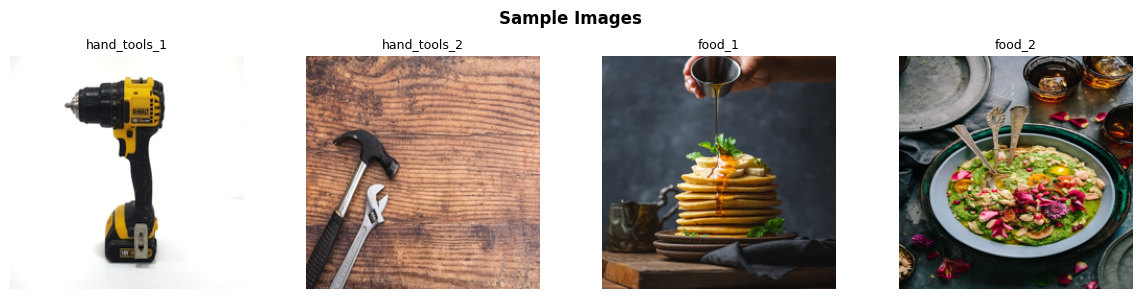

In [12]:
# Standard ImageNet normalization — used by both DINO and JEPA
IMAGENET_MEAN = (0.485, 0.456, 0.406)
IMAGENET_STD  = (0.229, 0.224, 0.225)

transform = T.Compose([
    T.Resize(256),
    T.CenterCrop(224),
    T.ToTensor(),
    T.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

def load_url_image(url: str) -> Image.Image:
    """Download an image from a URL."""
    response = requests.get(url, timeout=10)
    return Image.open(BytesIO(response.content)).convert('RGB')

def preprocess(img: Image.Image) -> torch.Tensor:
    """Preprocess a PIL image → normalized tensor [1, 3, H, W]."""
    return transform(img).unsqueeze(0).to(DEVICE)

# -----------------------------------------------------------------------
# Load sample images: two semantically SIMILAR + two DIFFERENT
# Feel free to replace with egocentric images from the IndEgo dataset!
# -----------------------------------------------------------------------
SAMPLE_URLS = {
    'hand_tools_1': 'https://images.unsplash.com/photo-1572981779307-38b8cabb2407?w=400',  # wrench
    'hand_tools_2': 'https://images.unsplash.com/photo-1586864387789-628af9feed72?w=400',  # screwdriver
    'food_1':       'https://images.unsplash.com/photo-1567620905732-2d1ec7ab7445?w=400',  # pancakes
    'food_2':       'https://images.unsplash.com/photo-1484980972926-edee96e0960d?w=400',  # breakfast
}

images_pil = {}
images_tensor = {}
for name, url in SAMPLE_URLS.items():
    try:
        img = load_url_image(url)
        images_pil[name] = img
        images_tensor[name] = preprocess(img)
        print(f'  ✓ {name}')
    except Exception as e:
        print(f'  ✗ {name}: {e}')

# Quick visual check
fig, axes = plt.subplots(1, len(images_pil), figsize=(12, 3))
for ax, (name, img) in zip(axes, images_pil.items()):
    ax.imshow(img.resize((224, 224)))
    ax.set_title(name, fontsize=9)
    ax.axis('off')
plt.suptitle('Sample Images', fontweight='bold')
plt.tight_layout()
plt.show()

---
## Part 3 — Task 1: Multi-Block Masking Strategy

I-JEPA uses a specific masking strategy: **4 contiguous spatial blocks** (scale 0.15–0.2 of image area) as targets, with the remaining patches as context.

This forces the predictor to reason about *spatial structure*, not just interpolate between scattered visible pixels.

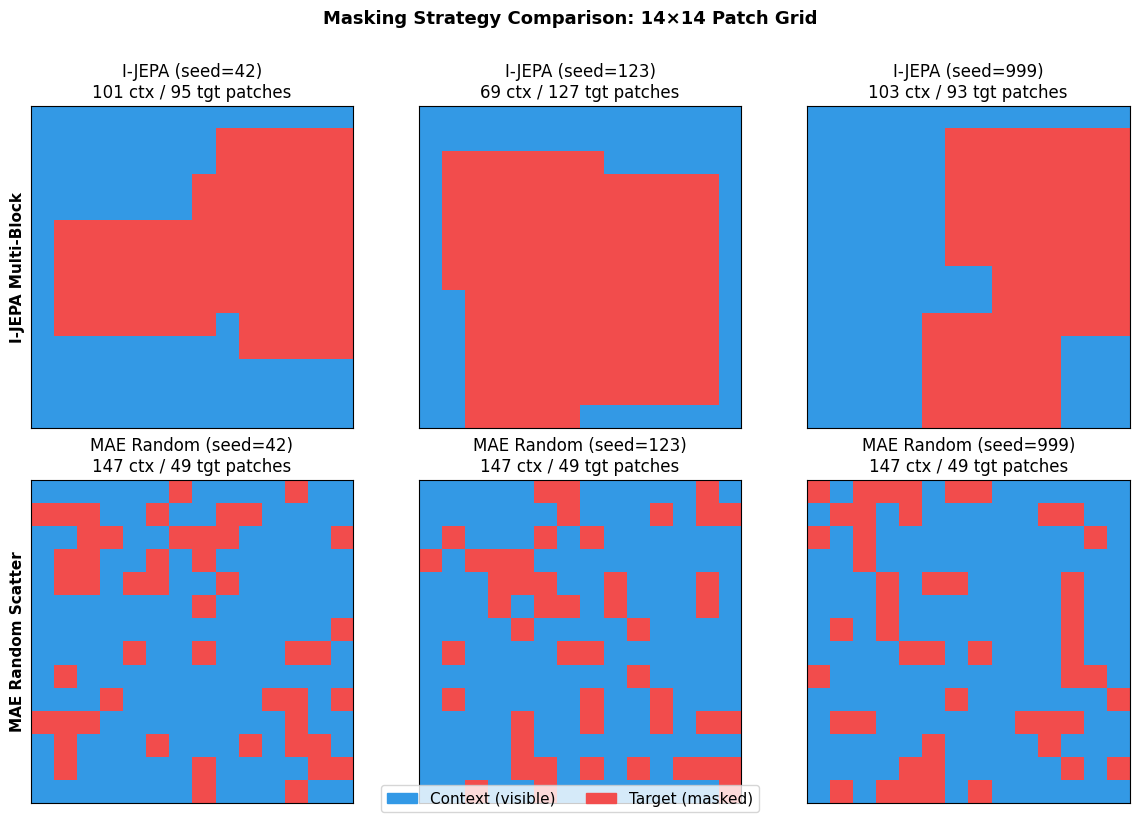


💡 Key insight: I-JEPA multi-block masking creates CONTIGUOUS target regions.
   The predictor must reason about entire object parts — not interpolate between neighbors.


In [13]:
def apply_multiblock_mask(
    grid_size: int = 14,
    num_target_blocks: int = 4,
    scale: tuple = (0.15, 0.2),
    aspect_ratio: tuple = (0.75, 1.5),
    seed: int = 42,
) -> tuple[np.ndarray, np.ndarray]:
    """
    Simulate I-JEPA's multi-block masking on a 14x14 patch grid.

    Returns
    -------
    context_mask : bool array [grid_size, grid_size], True = visible
    target_mask  : bool array [grid_size, grid_size], True = target
    """
    rng = np.random.default_rng(seed)
    total_patches = grid_size ** 2

    target_mask = np.zeros((grid_size, grid_size), dtype=bool)

    for _ in range(num_target_blocks):
        # Sample block area as fraction of total
        area_frac = rng.uniform(*scale)
        ar = rng.uniform(*aspect_ratio)

        block_h = max(1, int(round(np.sqrt(total_patches * area_frac / ar))))
        block_w = max(1, int(round(np.sqrt(total_patches * area_frac * ar))))
        block_h = min(block_h, grid_size)
        block_w = min(block_w, grid_size)

        top  = rng.integers(0, grid_size - block_h + 1)
        left = rng.integers(0, grid_size - block_w + 1)
        target_mask[top:top+block_h, left:left+block_w] = True

    # Context = complement of target (keep ~75% of patches)
    context_mask = ~target_mask
    return context_mask, target_mask


def apply_random_mask(grid_size: int = 14, keep_ratio: float = 0.75, seed: int = 42) -> tuple:
    """MAE-style random patch masking for comparison."""
    rng = np.random.default_rng(seed)
    n = grid_size ** 2
    indices = rng.permutation(n)
    keep = int(n * keep_ratio)
    ctx = np.zeros(n, dtype=bool)
    ctx[indices[:keep]] = True
    ctx = ctx.reshape(grid_size, grid_size)
    return ctx, ~ctx


# Visualize both strategies side by side
fig, axes = plt.subplots(2, 3, figsize=(12, 8))

for col, seed in enumerate([42, 123, 999]):
    ctx_jepa, tgt_jepa = apply_multiblock_mask(seed=seed)
    ctx_mae,  tgt_mae  = apply_random_mask(seed=seed)

    jepa_vis = np.zeros((14, 14, 3))
    jepa_vis[ctx_jepa] = [0.2, 0.6, 0.9]   # context = blue
    jepa_vis[tgt_jepa] = [0.95, 0.3, 0.3]  # target = red

    mae_vis = np.zeros((14, 14, 3))
    mae_vis[ctx_mae]  = [0.2, 0.6, 0.9]
    mae_vis[tgt_mae]  = [0.95, 0.3, 0.3]

    axes[0, col].imshow(jepa_vis, interpolation='nearest')
    axes[0, col].set_title(f'I-JEPA (seed={seed})\n{ctx_jepa.sum()} ctx / {tgt_jepa.sum()} tgt patches')
    axes[0, col].grid(True, color='white', linewidth=0.5)
    axes[0, col].set_xticks([]); axes[0, col].set_yticks([])

    axes[1, col].imshow(mae_vis, interpolation='nearest')
    axes[1, col].set_title(f'MAE Random (seed={seed})\n{ctx_mae.sum()} ctx / {tgt_mae.sum()} tgt patches')
    axes[1, col].grid(True, color='white', linewidth=0.5)
    axes[1, col].set_xticks([]); axes[1, col].set_yticks([])

axes[0, 0].set_ylabel('I-JEPA Multi-Block', fontsize=11, fontweight='bold')
axes[1, 0].set_ylabel('MAE Random Scatter', fontsize=11, fontweight='bold')

blue_patch = mpatches.Patch(color=(0.2,0.6,0.9), label='Context (visible)')
red_patch  = mpatches.Patch(color=(0.95,0.3,0.3), label='Target (masked)')
fig.legend(handles=[blue_patch, red_patch], loc='lower center', ncol=2, fontsize=11)

plt.suptitle('Masking Strategy Comparison: 14×14 Patch Grid', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

print("\n💡 Key insight: I-JEPA multi-block masking creates CONTIGUOUS target regions.")
print("   The predictor must reason about entire object parts — not interpolate between neighbors.")

> **❓ Question 1**: Why does using contiguous blocks (rather than scattered patches) create a harder — and more useful — prediction task? Think about what structure the predictor is forced to model.

---
## Part 4 — Task 2: Extract Patch Embeddings

We extract the patch token embeddings from the pretrained ViT encoder. These are the **context representations** in I-JEPA's framework.

In [14]:
@torch.no_grad()
def extract_patch_embeddings(model: nn.Module, img_tensor: torch.Tensor) -> torch.Tensor:
    """
    Extract patch token embeddings from a ViT.

    Returns
    -------
    patch_embeds : Tensor [N_patches, D]  (CLS token excluded)
    cls_embed    : Tensor [D]
    """
    # Forward pass — timm with global_pool='' returns [B, N+1, D]
    # where index 0 is [CLS], indices 1: are patch tokens
    out = model.forward_features(img_tensor)  # [1, 197, 768]

    cls_embed    = out[0, 0, :]     # [D=768]
    patch_embeds = out[0, 1:, :]    # [196, 768]

    # L2-normalize embeddings (standard for cosine similarity comparisons)
    patch_embeds = F.normalize(patch_embeds, dim=-1)
    cls_embed    = F.normalize(cls_embed, dim=-1)

    return patch_embeds, cls_embed


# Extract embeddings for all images
embeddings = {}
for name, tensor in images_tensor.items():
    patch_emb, cls_emb = extract_patch_embeddings(model, tensor)
    embeddings[name] = {'patch': patch_emb.cpu(), 'cls': cls_emb.cpu()}

print("Embedding shapes:")
for name, emb in embeddings.items():
    print(f"  {name:20s}  patch: {list(emb['patch'].shape)}  cls: {list(emb['cls'].shape)}")

# Sanity check: cosine similarity of an embedding with itself should be 1.0
z = embeddings[list(embeddings.keys())[0]]['patch']
self_sim = (z * z).sum(-1)  # dot product after L2 norm = cosine sim with self
print(f"\nSelf-similarity range: [{self_sim.min():.4f}, {self_sim.max():.4f}]  (should be ~1.0)")

Embedding shapes:
  hand_tools_1          patch: [196, 768]  cls: [768]
  hand_tools_2          patch: [196, 768]  cls: [768]
  food_1                patch: [196, 768]  cls: [768]
  food_2                patch: [196, 768]  cls: [768]

Self-similarity range: [1.0000, 1.0000]  (should be ~1.0)


---
## Part 5 — Task 3: Cosine Similarity Heatmaps

This is the **core diagnostic** for evaluating the quality of learned representations.  
If the embedding space is semantically organized, patches from structurally similar regions of similar images should have high cosine similarity.

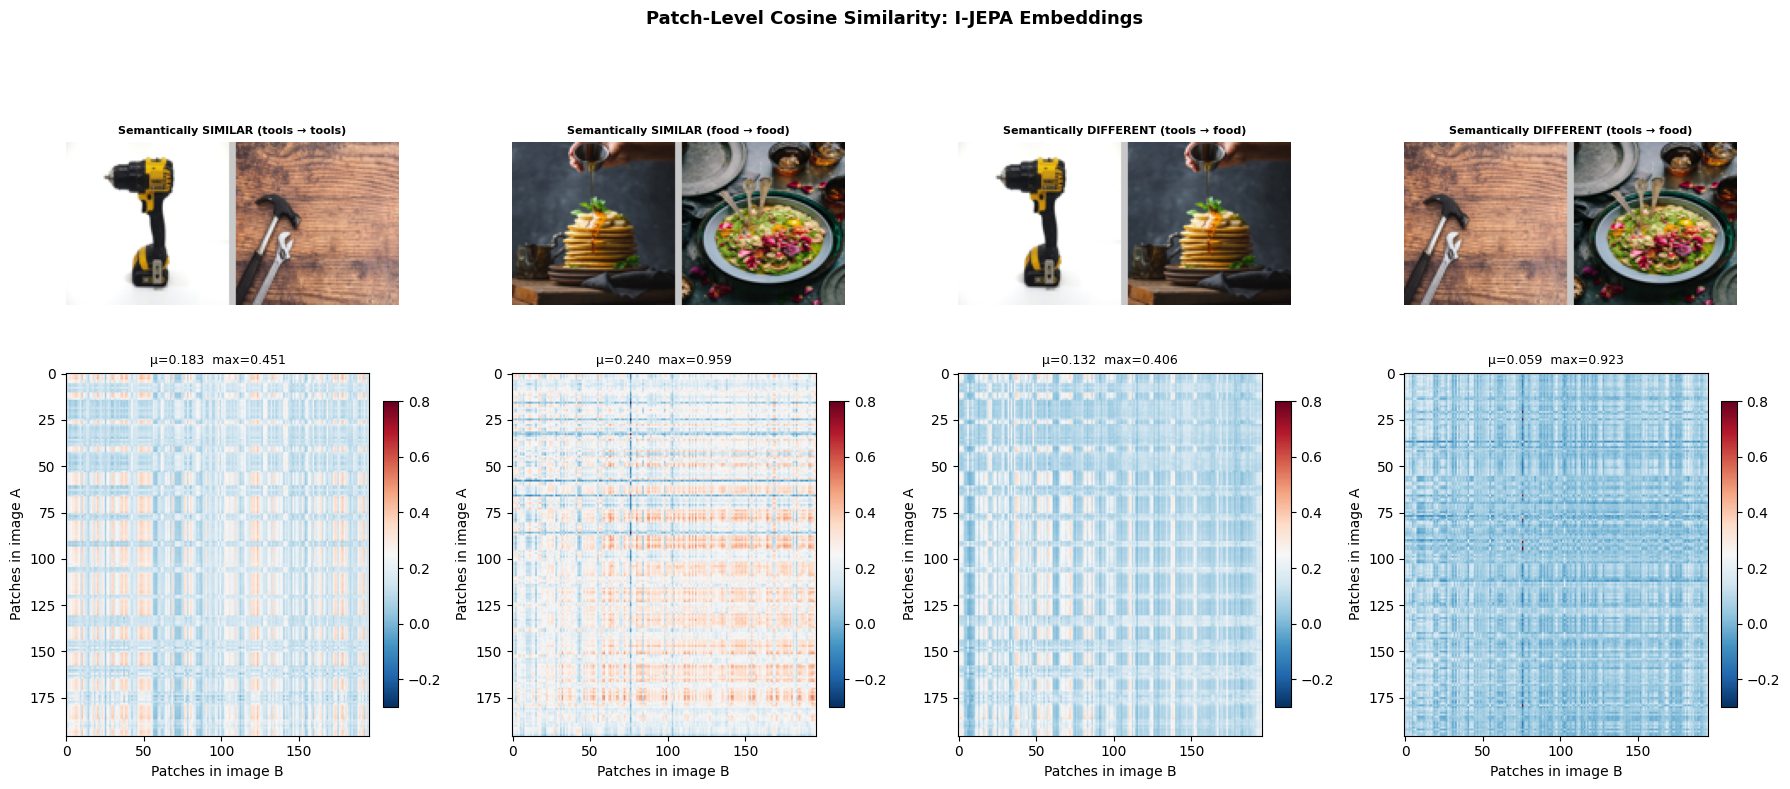


📊 Summary statistics:
  Semantically SIMILAR (tools → tools)           mean=0.1831  max=0.4511
  Semantically SIMILAR (food → food)             mean=0.2395  max=0.9595
  Semantically DIFFERENT (tools → food)          mean=0.1325  max=0.4057
  Semantically DIFFERENT (tools → food)          mean=0.0588  max=0.9229


In [15]:
def patch_cosine_similarity_matrix(
    emb_a: torch.Tensor,  # [N, D]
    emb_b: torch.Tensor,  # [M, D]
) -> torch.Tensor:
    """
    Compute pairwise cosine similarity between all patches of image A and all patches of B.

    Returns: [N, M] similarity matrix (values in [-1, 1])

    Implementation note: since embeddings are already L2-normalized,
    cosine_sim(a, b) = a · b  (matrix multiplication)
    """
    # YOUR TURN: implement this
    # Hint: a single matrix multiplication gives you all pairwise dot products
    # ------ SOLUTION (remove before distributing to students) ------
    return emb_a @ emb_b.T  # [N, M]
    # ---------------------------------------------------------------


# Compare four image pairs
names = list(embeddings.keys())
pairs = [
    ('hand_tools_1', 'hand_tools_2', 'Semantically SIMILAR (tools → tools)'),
    ('food_1',       'food_2',       'Semantically SIMILAR (food → food)'),
    ('hand_tools_1', 'food_1',       'Semantically DIFFERENT (tools → food)'),
    ('hand_tools_2', 'food_2',       'Semantically DIFFERENT (tools → food)'),
]

fig, axes = plt.subplots(2, 4, figsize=(18, 8))

for col, (name_a, name_b, title) in enumerate(pairs):
    if name_a not in embeddings or name_b not in embeddings:
        continue

    z_a = embeddings[name_a]['patch']   # [196, 768]
    z_b = embeddings[name_b]['patch']   # [196, 768]

    sim_matrix = patch_cosine_similarity_matrix(z_a, z_b).numpy()  # [196, 196]

    # Show images
    side = np.array(images_pil[name_a].resize((96, 96)))
    side = np.concatenate([side, np.full((96, 4, 3), 200, dtype=np.uint8),
                           np.array(images_pil[name_b].resize((96, 96)))], axis=1)
    axes[0, col].imshow(side)
    axes[0, col].set_title(title, fontsize=8, fontweight='bold', wrap=True)
    axes[0, col].axis('off')

    # Show similarity matrix
    im = axes[1, col].imshow(sim_matrix, cmap='RdBu_r', vmin=-0.3, vmax=0.8, aspect='auto')
    axes[1, col].set_xlabel('Patches in image B')
    axes[1, col].set_ylabel('Patches in image A')
    axes[1, col].set_title(f'μ={sim_matrix.mean():.3f}  max={sim_matrix.max():.3f}', fontsize=9)
    plt.colorbar(im, ax=axes[1, col], fraction=0.046, pad=0.04)

plt.suptitle('Patch-Level Cosine Similarity: I-JEPA Embeddings', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print("\n📊 Summary statistics:")
for name_a, name_b, title in pairs:
    if name_a not in embeddings or name_b not in embeddings:
        continue
    sim = patch_cosine_similarity_matrix(
        embeddings[name_a]['patch'], embeddings[name_b]['patch']
    ).numpy()
    print(f"  {title[:45]:45s}  mean={sim.mean():.4f}  max={sim.max():.4f}")

> **❓ Question 2**: What do you observe about the diagonal structure in the similarity matrices? Why might similar images show a block-diagonal pattern rather than a pure diagonal?

---
## Part 6 — Task 4: Embedding-Space Anomaly Score 🚨

**This is the most project-relevant task.**  

The core idea of the project's *Intrinsic Anomaly Detection* task (research goal 2) is that **procedural anomalies cause a mismatch between the observed video embedding and the expected embedding for that step** of the procedure.

We implement a simplified version: the anomaly score between a *reference* (normal) clip and an *observed* clip is the embedding distance.

Simulating procedural anomaly detection...
Reference: hand_tools_1 (expected 'tool interaction' embedding)

  Step 1 — Prep tool                   score=0.0000  ✓ Normal
  Step 2 — Position tool               score=0.8328  ✓ Normal
  Step 3 — Apply tool                  score=0.0000  ✓ Normal
  Step 4 — Adjust position             score=0.8328  ✓ Normal
  Step 5 — ⚠️  ANOMALY: food!          score=0.8516  ⚠️  ANOMALY
  Step 6 — Resume tool use             score=0.0000  ✓ Normal


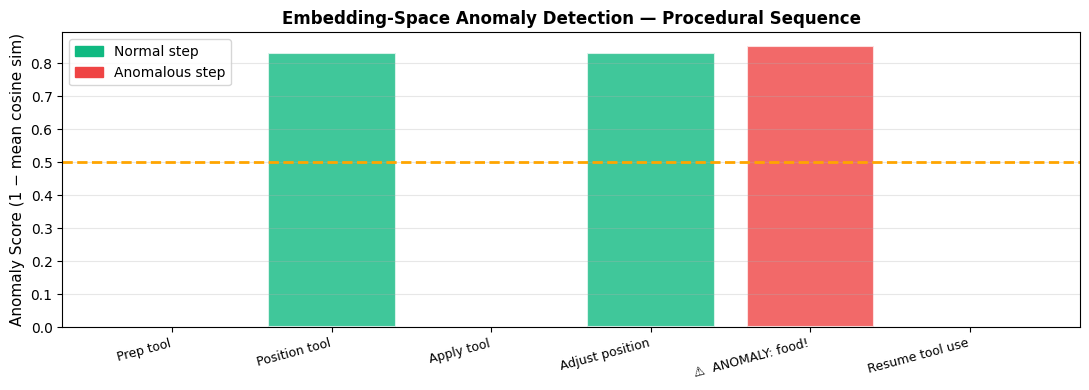

In [16]:
# ─────────────────────────────────────────────────────────────────────────────
# Simulate a simple procedural video anomaly scenario
# In the full project: replace this with actual IndEgo video frames
# ─────────────────────────────────────────────────────────────────────────────

# We'll use real images from two semantic classes as a proxy:
# - 'Normal' sequence: a set of frames showing consistent tool-use actions
# - 'Anomalous' frame: an unexpected frame (food instead of tools → step was skipped / wrong action)

@torch.no_grad()
def anomaly_score_l2(
    z_reference: torch.Tensor,   # [N_patches, D] expected state embedding
    z_observed: torch.Tensor,    # [N_patches, D] observed state embedding
) -> float:
    """
    Compute anomaly score between two frame embeddings.

    Formula: score = 1 - mean(cosine_similarity(z_ref, z_obs))
    High score → high discrepancy → potential anomaly

    Note: both embeddings are L2-normalized, so dot product = cosine similarity.
    """
    # YOUR TURN: implement this
    # Hint: for each patch, compute cosine similarity, then average over patches
    # ------ SOLUTION (remove before distributing to students) ------
    cos_sim_per_patch = (z_reference * z_observed).sum(dim=-1)  # [N] element-wise, then sum over D
    return float(1.0 - cos_sim_per_patch.mean())
    # ---------------------------------------------------------------


# Simulate a 6-step procedure:
# Steps 1-4 use tool images (normal)
# Step 5 anomaly: food image appears instead of tool (skipped step / wrong object)
# Step 6 back to tools (procedure continues)

print("Simulating procedural anomaly detection...")
print("Reference: hand_tools_1 (expected 'tool interaction' embedding)\n")

reference = embeddings['hand_tools_1']['patch']

procedure_steps = [
    ('Step 1 — Prep tool',         'hand_tools_1',  False),
    ('Step 2 — Position tool',     'hand_tools_2',  False),
    ('Step 3 — Apply tool',        'hand_tools_1',  False),
    ('Step 4 — Adjust position',   'hand_tools_2',  False),
    ('Step 5 — ⚠️  ANOMALY: food!', 'food_1',        True),  # wrong action/object
    ('Step 6 — Resume tool use',   'hand_tools_1',  False),
]

step_names, scores, is_anomaly = [], [], []
for step_name, img_name, anomaly in procedure_steps:
    if img_name in embeddings:
        z_obs = embeddings[img_name]['patch']
        score = anomaly_score_l2(reference, z_obs)
        step_names.append(step_name)
        scores.append(score)
        is_anomaly.append(anomaly)
        flag = '⚠️  ANOMALY' if anomaly else '✓ Normal'
        print(f"  {step_name:35s}  score={score:.4f}  {flag}")

# Plot the anomaly timeline
fig, ax = plt.subplots(figsize=(11, 4))
colors = ['#EF4444' if a else '#10B981' for a in is_anomaly]
bars = ax.bar(range(len(scores)), scores, color=colors, alpha=0.8, edgecolor='white', linewidth=1.5)
ax.axhline(np.mean([s for s, a in zip(scores, is_anomaly) if not a]) * 1.5,
           color='orange', linestyle='--', linewidth=2, label='Detection threshold (1.5× normal mean)')

ax.set_xticks(range(len(step_names)))
ax.set_xticklabels([s.split('—')[-1].strip() for s in step_names], rotation=15, ha='right', fontsize=9)
ax.set_ylabel('Anomaly Score (1 − mean cosine sim)', fontsize=11)
ax.set_title('Embedding-Space Anomaly Detection — Procedural Sequence', fontsize=12, fontweight='bold')

normal_patch  = mpatches.Patch(color='#10B981', label='Normal step')
anomaly_patch = mpatches.Patch(color='#EF4444', label='Anomalous step')
ax.legend(handles=[normal_patch, anomaly_patch], loc='upper left')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

---
## Part 7 — UMAP Embedding Space Visualization

UMAP (Uniform Manifold Approximation and Projection) gives us a 2D view of the embedding space structure.

Reducing 784 patch embeddings (dim=768) to 2D...


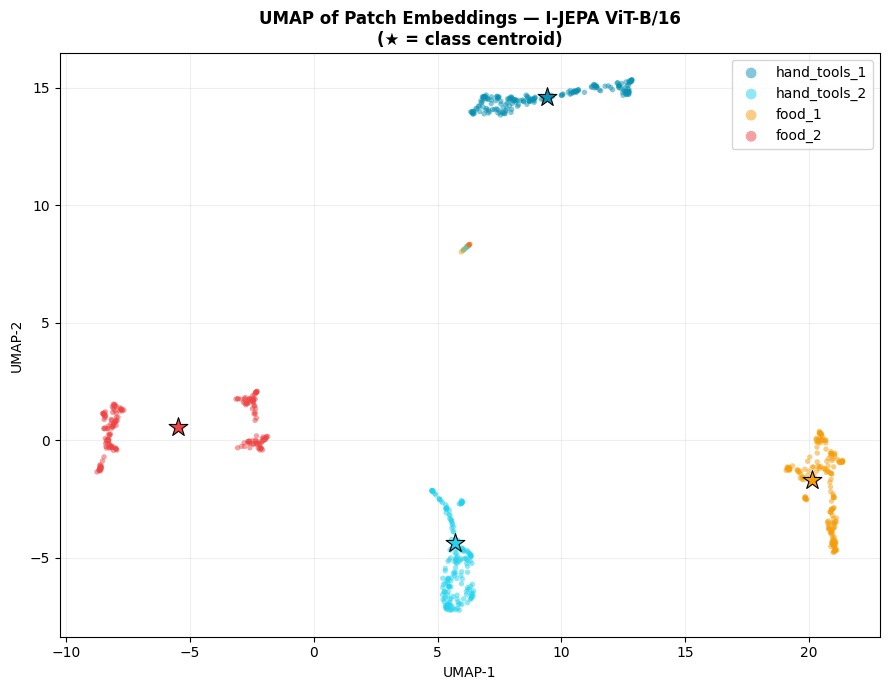


Centroid-to-centroid cosine distances:
  hand_tools_1         ↔ hand_tools_2          cos_sim=0.1977
  hand_tools_1         ↔ food_1                cos_sim=0.1490
  hand_tools_1         ↔ food_2                cos_sim=0.0420
  hand_tools_2         ↔ food_1                cos_sim=0.1004
  hand_tools_2         ↔ food_2                cos_sim=0.0904
  food_1               ↔ food_2                cos_sim=0.3131


In [17]:
from sklearn.decomposition import PCA
import warnings

try:
    from umap import UMAP
    use_umap = True
except ImportError:
    use_umap = False
    print('UMAP not available, falling back to PCA')

# Collect all patch embeddings with labels
all_embeds, all_labels = [], []
COLORS = {'hand_tools_1': '#0891B2', 'hand_tools_2': '#22D3EE',
           'food_1': '#F59E0B', 'food_2': '#EF4444'}

for name, emb_dict in embeddings.items():
    patches = emb_dict['patch'].numpy()  # [196, 768]
    all_embeds.append(patches)
    all_labels.extend([name] * patches.shape[0])

X = np.concatenate(all_embeds, axis=0)  # [196*4, 768]
print(f'Reducing {X.shape[0]} patch embeddings (dim={X.shape[1]}) to 2D...')

with warnings.catch_warnings():
    warnings.simplefilter('ignore')
    if use_umap:
        reducer = UMAP(n_components=2, n_neighbors=30, min_dist=0.1, metric='cosine', random_state=42)
    else:
        reducer = PCA(n_components=2)
    X_2d = reducer.fit_transform(X)

method_name = 'UMAP' if use_umap else 'PCA'

fig, ax = plt.subplots(figsize=(9, 7))
n = 196  # patches per image
for i, (name, color) in enumerate(COLORS.items()):
    chunk = X_2d[i*n:(i+1)*n]
    ax.scatter(chunk[:, 0], chunk[:, 1], c=color, label=name, alpha=0.5, s=15, edgecolors='none')
    # Mark centroid
    cx, cy = chunk.mean(0)
    ax.scatter(cx, cy, c=color, s=200, marker='*', edgecolors='black', linewidths=0.8, zorder=5)

ax.set_title(f'{method_name} of Patch Embeddings — I-JEPA ViT-B/16\n(★ = class centroid)', fontsize=12, fontweight='bold')
ax.legend(fontsize=10, markerscale=2)
ax.set_xlabel(f'{method_name}-1'); ax.set_ylabel(f'{method_name}-2')
ax.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()

print(f"\nCentroid-to-centroid cosine distances:")
name_list = list(COLORS.keys())
for i in range(len(name_list)):
    for j in range(i+1, len(name_list)):
        ci = embeddings[name_list[i]]['cls'].unsqueeze(0)  # [1, D] (already normalized)
        cj = embeddings[name_list[j]]['cls'].unsqueeze(0)
        sim = (ci * cj).sum().item()
        print(f"  {name_list[i]:20s} ↔ {name_list[j]:20s}  cos_sim={sim:.4f}")

---
## Part 8 — Simulated EMA Target Encoder

The **stop-gradient + EMA target encoder** is the critical mechanism that prevents mode collapse in JEPA.  
This cell demonstrates EMA update dynamics.

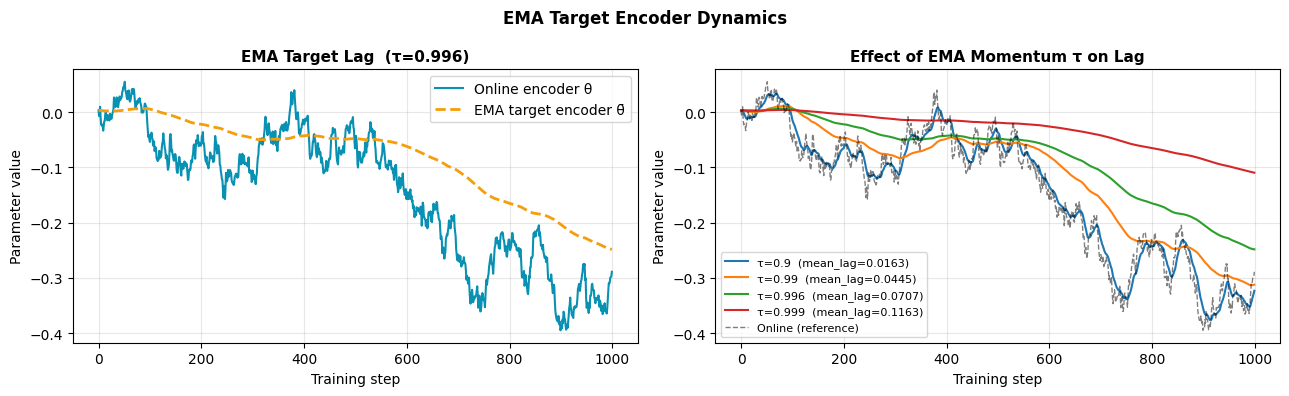


💡 The EMA target provides STABLE regression targets.
   τ=0.996 means the target updates ~0.4% per step — slow enough to prevent collapse,
   fast enough to keep up with the online encoder's learning.


In [ ]:
class EMAEncoder:
    """
    Exponential Moving Average encoder — the core of JEPA's collapse prevention.

    Update rule:  θ_target ← τ * θ_target  +  (1-τ) * θ_context

    Key property: θ_target receives NO gradient.
    It is a slowly-evolving copy of the online encoder.
    """

    def __init__(self, online_model: nn.Module, momentum: float = 0.996):
        self.target = deepcopy(online_model)
        self.target.requires_grad_(False)  # ← NO GRADIENTS THROUGH TARGET
        self.momentum = momentum
        self.step = 0

    @torch.no_grad()
    def update(self, online_model: nn.Module):
        """Call after each optimizer step."""
        τ = self.momentum
        for θ_target, θ_online in zip(self.target.parameters(), online_model.parameters()):
            θ_target.data.mul_(τ).add_((1 - τ) * θ_online.data)
        self.step += 1

    @property
    def current_momentum(self):
        return self.momentum


# Visualize parameter divergence over training steps
# Simulate how target lags behind online encoder
n_steps = 1000
momentum = 0.996

# Simulate a single parameter tracking
online_param = np.zeros(n_steps)
target_param = np.zeros(n_steps)

# Online parameter follows a random walk (gradient updates)
rng = np.random.default_rng(42)
delta = rng.normal(0, 0.01, n_steps).cumsum()  # simulated gradient trajectory
online_param = delta

# Target tracks online with EMA
target_param[0] = online_param[0]
for t in range(1, n_steps):
    target_param[t] = momentum * target_param[t-1] + (1 - momentum) * online_param[t]

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(online_param, label='Online encoder θ', color='#0891B2', linewidth=1.5)
axes[0].plot(target_param, label='EMA target encoder θ̄', color='#F59E0B', linewidth=2, linestyle='--')
axes[0].set_title(f'EMA Target Lag  (τ={momentum})', fontsize=11, fontweight='bold')
axes[0].set_xlabel('Training step'); axes[0].set_ylabel('Parameter value')
axes[0].legend(); axes[0].grid(alpha=0.3

# Show response curves for different τ values
for τ in [0.9, 0.99, 0.996, 0.999]:
    tp = np.zeros(n_steps)
    tp[0] = online_param[0]
    for t in range(1, n_steps):
        tp[t] = τ * tp[t-1] + (1-τ) * online_param[t]
    lag = np.mean(np.abs(online_param - tp))
    axes[1].plot(tp, label=f'τ={τ}  (mean_lag={lag:.4f})', linewidth=1.5)

axes[1].plot(online_param, 'k--', linewidth=1, alpha=0.5, label='Online (reference)')
axes[1].set_title('Effect of EMA Momentum τ on Lag', fontsize=11, fontweight='bold')
axes[1].set_xlabel('Training step'); axes[1].set_ylabel('Parameter value')
axes[1].legend(fontsize=8); axes[1].grid(alpha=0.3)

plt.suptitle('EMA Target Encoder Dynamics', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

print("\n💡 The EMA target provides STABLE regression targets.")
print("   τ=0.996 means the target updates ~0.4% per step — slow enough to prevent collapse,")
print("   fast enough to keep up with the online encoder's learning.")

---
## Part 9 — BONUS: Temporal Prediction Simulation

VL-JEPA extends I-JEPA to video by predicting embeddings at **future time steps**.  
This cell simulates temporal prediction quality using image pairs as a proxy for consecutive video frames.

In [19]:
class SimpleTemporalPredictor(nn.Module):
    """
    Simplified temporal predictor module.

    In full VL-JEPA, this is a multi-layer Transformer with cross-attention to language.
    Here we use a 2-layer MLP as a proof-of-concept.

    Input:  z_t       [B, N, D]  — context frame embeddings
    Output: ẑ_{t+k}  [B, N, D]  — predicted future embeddings
    """
    def __init__(self, embed_dim: int = 768, hidden_dim: int = 384):
        super().__init__()
        self.mlp = nn.Sequential(
            nn.Linear(embed_dim, hidden_dim),
            nn.GELU(),
            nn.LayerNorm(hidden_dim),
            nn.Linear(hidden_dim, embed_dim),
        )
        # Initialize as near-identity: predict z_t ≈ z_{t+1} for small k
        nn.init.zeros_(self.mlp[-1].weight)
        nn.init.zeros_(self.mlp[-1].bias)

    def forward(self, z_t: torch.Tensor) -> torch.Tensor:
        # Residual connection: predict the delta, not the full embedding
        return F.normalize(z_t + self.mlp(z_t), dim=-1)


# Demonstrate the prediction loss computation
predictor = SimpleTemporalPredictor(embed_dim=768).to(DEVICE)

z_t   = embeddings['hand_tools_1']['patch'].unsqueeze(0).to(DEVICE)  # [1, 196, 768]
z_tp1 = embeddings['hand_tools_2']['patch'].unsqueeze(0).to(DEVICE)  # [1, 196, 768] — "next frame"

# Forward pass
z_pred = predictor(z_t)  # [1, 196, 768]

# JEPA loss: L2 in normalized embedding space (no gradient through target)
loss = F.mse_loss(z_pred, z_tp1.detach())

print("Temporal Predictor Demo:")
print(f"  z_t shape:     {z_t.shape}")
print(f"  z_pred shape:  {z_pred.shape}")
print(f"  JEPA MSE loss: {loss.item():.6f}  (before training — random predictor)")

# Prediction quality: mean cosine similarity before/after one gradient step
initial_sim = (z_pred.detach() * z_tp1).sum(-1).mean().item()
print(f"  Mean cos sim (pred, target): {initial_sim:.4f}  (should improve with training)")

# One gradient step
opt = torch.optim.AdamW(predictor.parameters(), lr=1e-3)
for _ in range(100):
    z_pred = predictor(z_t)
    loss = F.mse_loss(z_pred, z_tp1.detach())
    opt.zero_grad(); loss.backward(); opt.step()

z_pred_trained = predictor(z_t).detach()
trained_sim = (z_pred_trained * z_tp1).sum(-1).mean().item()
print(f"  After 100 steps: loss={loss.item():.6f}  cos_sim={trained_sim:.4f}")

Temporal Predictor Demo:
  z_t shape:     torch.Size([1, 196, 768])
  z_pred shape:  torch.Size([1, 196, 768])
  JEPA MSE loss: 0.002169  (before training — random predictor)
  Mean cos sim (pred, target): 0.1672  (should improve with training)
  After 100 steps: loss=0.000635  cos_sim=0.7564


---
## 🏁 Summary & Project Connections

| Workshop task | What you learned | Project connection |
|---|---|---|
| Multi-block masking | Structural masking forces spatial reasoning | Egocentric clip masking for action anticipation |
| Patch embedding extraction | L2-normalized embeddings + EMA encoder | Feature extraction backbone for all tasks |
| Cosine similarity heatmaps | Semantic structure of embedding space | Cross-modal alignment (Task 3) |
| Anomaly scoring | Embedding distance as anomaly signal | **Task 2: Intrinsic Anomaly Detection** |
| UMAP visualization | Semantic clustering of embeddings | Diagnostic tool for project experiments |
| EMA dynamics | Collapse prevention mechanism | Training stability for Task 1 fine-tuning |

### Next steps before the project sprint
1. Download the [I-JEPA ViT-H/14 checkpoint](https://github.com/facebookresearch/ijepa) (Meta FAIR GitHub)
2. Apply the anomaly score (Task 4) to real clips from the IndEgo dataset
3. Read [VL-JEPA paper §3.2](https://arxiv.org/abs/2512.10942) on cross-modal energy

---
*Workshop prepared by Ashwin Nedungadi & NEidl Team | Rostock–Cluj Collaboration | Summer 2026*